# Trajectory Inference and Pseudotime

In [1]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib import rcParams
import scanpy as sc
import scvelo as scv

import scipy
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action="ignore", category=Warning)

In [2]:
adata = scv.datasets.pancreas()
adata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

In [3]:
adata.obs["clusters"].value_counts()

clusters
Ductal           916
Ngn3 high EP     642
Pre-endocrine    592
Beta             591
Alpha            481
Ngn3 low EP      262
Epsilon          142
Delta             70
Name: count, dtype: int64

In [ ]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, subset=True)
adata = adata[:, adata.var["highly_variable"]].copy()
sc.tl.pca(adata)
sc.pl.pca(adata, color='clusters')

In [6]:
sc.pp.neighbors(adata, n_pcs = 30, n_neighbors = 50)
sc.tl.umap(adata, min_dist=0.4, spread=3)

In [ ]:
sc.pl.umap(adata, color = ['clusters'],
           legend_loc = 'on data', edges = True)

In [ ]:
# using the umap to initialize the graph layout.
sc.tl.draw_graph(adata, init_pos='X_umap')
sc.pl.draw_graph(adata, color='clusters', legend_loc='on data', legend_fontsize = 'xx-small')

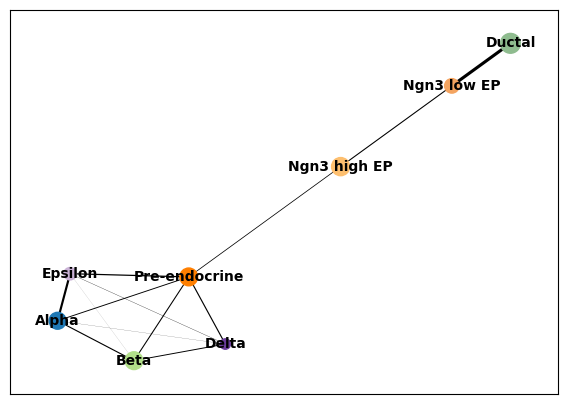

In [9]:
sc.tl.paga(adata, groups='clusters')
sc.pl.paga(adata, color='clusters', edge_width_scale = 0.3)

In [10]:
sc.tl.draw_graph(adata, init_pos='paga')

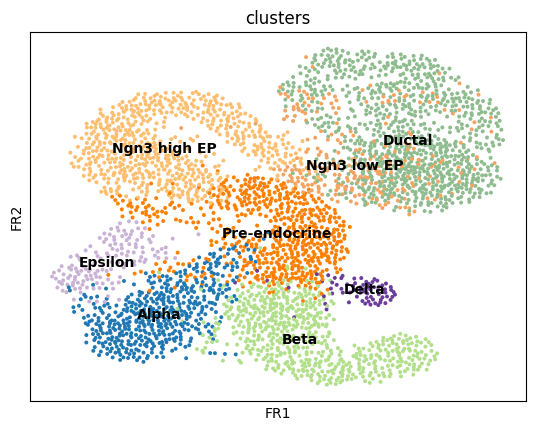

In [11]:
sc.pl.draw_graph(adata, color=['clusters'], legend_loc='on data')

## Gene changes

We can reconstruct gene changes along PAGA paths for a given set of
genes

By looking at the different know lineages and the layout of the graph we
define manually some paths to the graph that corresponds to specific
lineages.

In [17]:
# Define paths
paths = [('beta', ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Beta']),
        ('alpha', ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Alpha']),
        ('delta', ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Delta']),
        ('epsilon', ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Epsilon'])]

adata.obs['distance'] = adata.obs['dpt_pseudotime']

Then we select some genes that can vary in the lineages and plot onto
the paths.

In [18]:
sc.tl.rank_genes_groups(adata, "clusters", method="t-test", n_genes=10)

In [19]:
pd.DataFrame(adata.uns["rank_genes_groups"]["names"])

,Ductal,Ngn3 low EP,Ngn3 high EP,Pre-endocrine,Beta,Alpha,Delta,Epsilon
0,Spp1,Spp1,Neurog3,Map1b,Pcsk2,Cpe,Rbp4,Ghrl
1,Dbi,Dbi,Btbd17,Fev,Rbp4,Tmem27,Hhex,Isl1
2,Cldn3,Sparc,Sox4,Hmgn3,Mafb,Pcsk1n,Hmgn3,Rbp4
3,Mgst1,Mgst1,Mdk,Bex2,Sec61b,Tspan7,Isl1,Bex2
4,Anxa2,1700011H14Rik,Gadd45a,Ypel3,Cpe,Meis2,Fam183b,Fam183b
5,Bicc1,Cldn3,Smarcd2,Chga,Gng12,Gpx3,Hadh,Maged2
6,Krt18,Anxa2,Btg2,Emb,Pcsk1n,Fam183b,Arg1,Cck
7,Mt1,Clu,Tmsb4x,Cpe,Rap1b,Slc38a5,Sst,Anpep
8,Clu,Vim,Hes6,Cryba2,Tuba1a,Slc25a5,Gpx3,Card19
9,1700011H14Rik,Mt1,Cd63,Glud1,1700086L19Rik,Hmgn3,Dlk1,Arg1


In [22]:
gene_names = ["Spp1", "Dbi", "Cldn3", "Sparc", "Mgst1", "Cldn3", "Neurog3", "Btbd17", "Sox4",
              "Map1b", "Fev", "Hmgn3", "Bex2", "Sec61b", "Tuba1a", "Meis2", "Pcsk1n", "Sst", "Arg1",
              "Rbp4", "Hhex", "Ghrl", "Isl1", "Rbp4", "Bex2"]

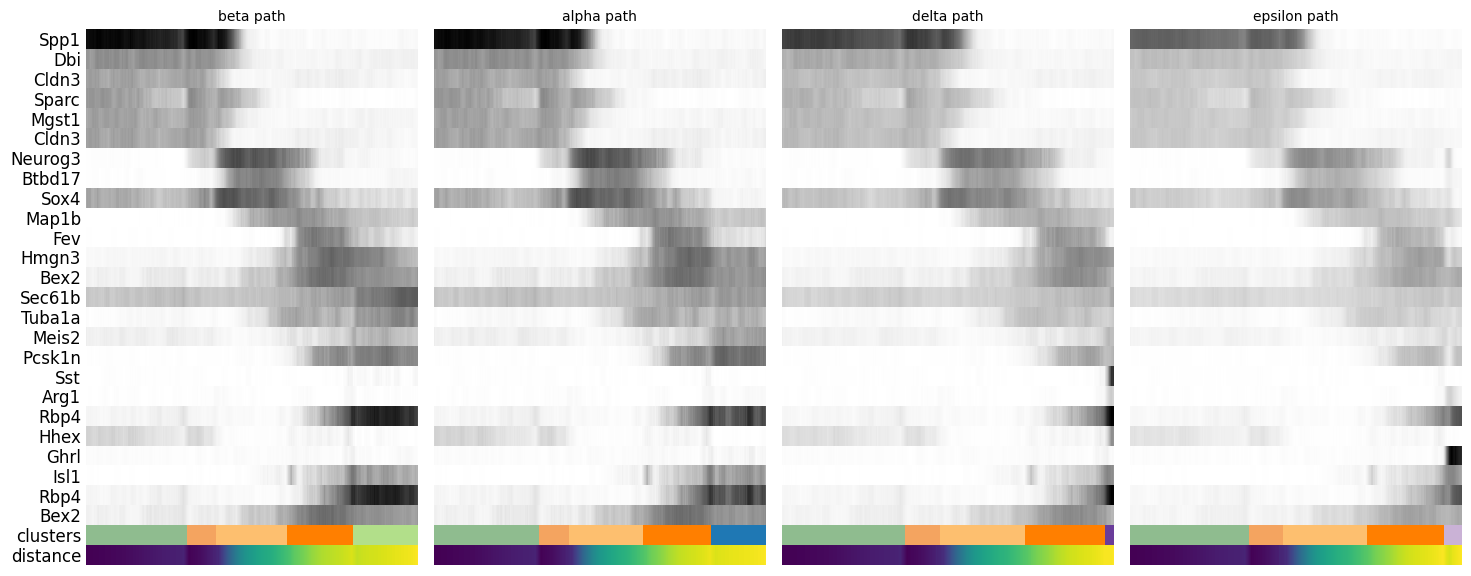

In [23]:
_, axs = pl.subplots(ncols=4, figsize=(16, 8), gridspec_kw={
                     'wspace': 0.05, 'left': 0.12})
pl.subplots_adjust(left=0.05, right=0.98, top=0.82, bottom=0.2)
for ipath, (descr, path) in enumerate(paths):
    _, data = sc.pl.paga_path(
        adata, path, gene_names,
        show_node_names=False,
        ax=axs[ipath],
        ytick_fontsize=12,
        left_margin=0.15,
        n_avg=50,
        annotations=['distance'],
        show_yticks=True if ipath == 0 else False,
        show_colorbar=False,
        color_map='Greys',
        groups_key='clusters',
        color_maps_annotations={'distance': 'viridis'},
        title='{} path'.format(descr),
        return_data=True,
        use_raw=False,
        show=False)
pl.show()

# Diffusion pseudotime

We can also define pseudotime at the level of the cells. Here we need to choose a "root" cell for diffusion pseudotime, which we do from the Ductal cells.

In [12]:
adata.uns['iroot'] = np.flatnonzero(adata.obs['clusters']  == 'Ductal')[0]

In [ ]:
sc.tl.diffmap(adata)
sc.tl.dpt(adata)

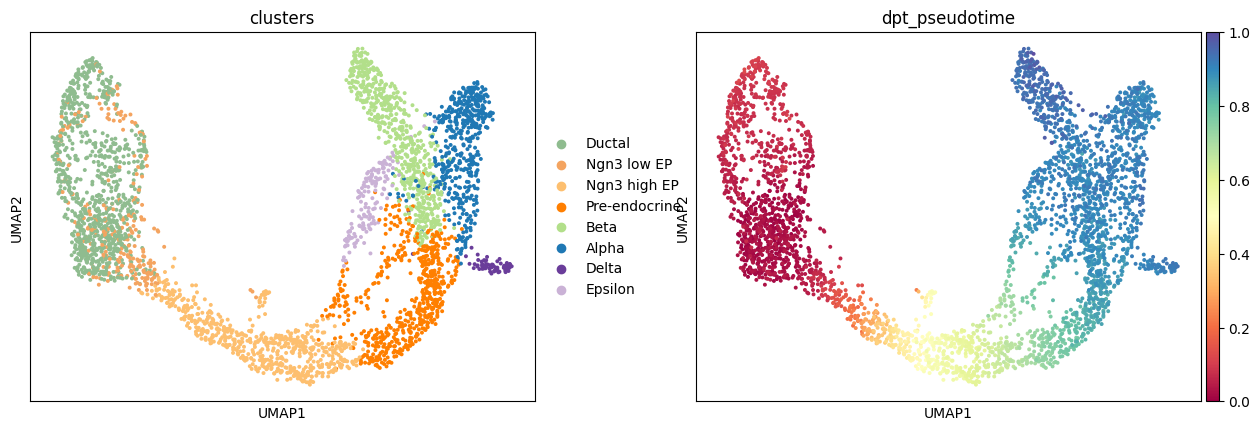

In [15]:
adata.obsm["X_umap"] = scv.datasets.pancreas().obsm["X_umap"]
sc.pl.umap(adata, color=['clusters', 'dpt_pseudotime'], cmap=plt.cm.Spectral, wspace=0.2)